In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(-0.5, 735.5, 735.5, -0.5)

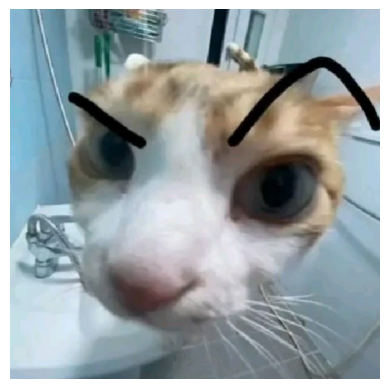

In [7]:
img = cv2.imread("/Users/230150/Downloads/catmeme.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")

1) Flipping the image

Text(0.5, 1.0, 'Vertical')

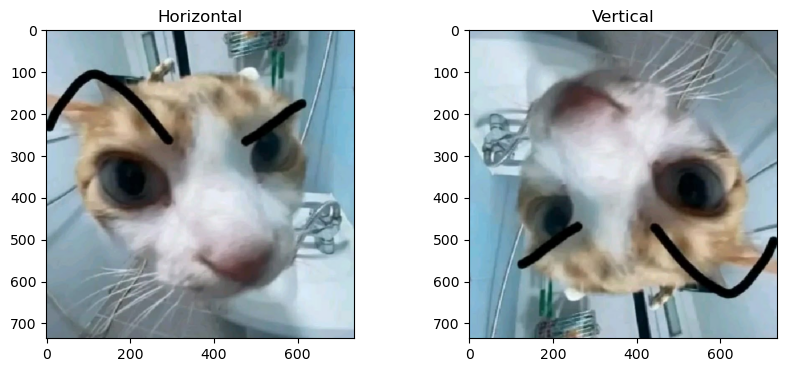

In [8]:
def flip_image(image):
    horizontal = cv2.flip(image, 1)   # mirror left-right
    vertical = cv2.flip(image, 0)     # upside-down
    return horizontal, vertical

h, v = flip_image(img)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(h, cv2.COLOR_BGR2RGB)); plt.title("Horizontal")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(v, cv2.COLOR_BGR2RGB)); plt.title("Vertical")


1) Mirrored

(-0.5, 1471.5, 735.5, -0.5)

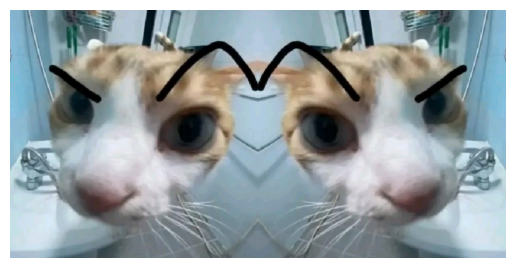

In [9]:
def mirror_effect(image):
    mirror = cv2.flip(image, 1)
    combined = np.hstack((image, mirror))
    return combined

mirror_img = mirror_effect(img)

plt.imshow(cv2.cvtColor(mirror_img, cv2.COLOR_BGR2RGB))
plt.axis("off")


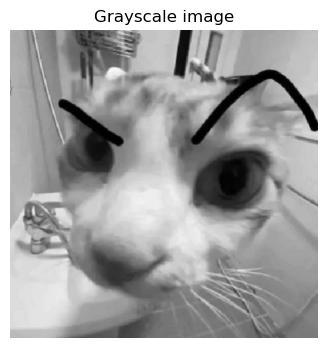

In [26]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(5,4))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale image")
plt.axis("off")
plt.show()

PART 2
1) Image Negative

(-0.5, 735.5, 735.5, -0.5)

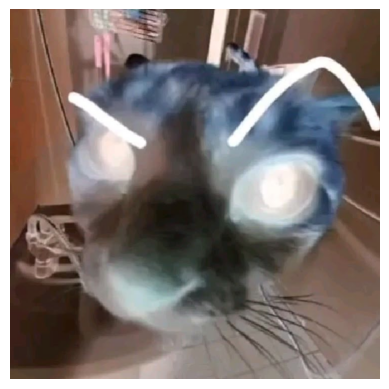

In [27]:
negative = 255 - img

plt.imshow(cv2.cvtColor(negative, cv2.COLOR_BGR2RGB))
plt.axis("off")


2)Gamma curves (non- nurmalized)

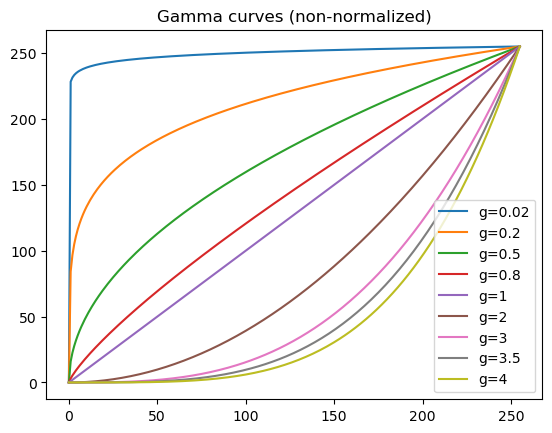

In [16]:
gammas = [0.02,0.2,0.5,0.8,1,2,3,3.5,4]
x = np.arange(0,256)

plt.figure()
for g in gammas:
    y = 255*((x/255)**g)
    plt.plot(x,y,label=f"g={g}")

plt.legend()
plt.title("Gamma curves (non-normalized)")
plt.show()


3)Normalized

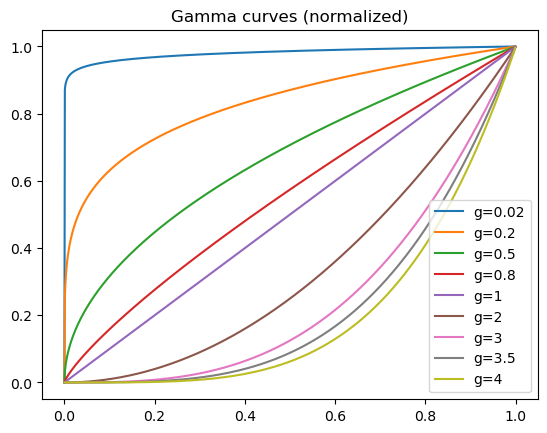

In [17]:
x = np.arange(0,1,0.001)

plt.figure()
for g in gammas:
    y = x**g
    plt.plot(x,y,label=f"g={g}")

plt.legend()
plt.title("Gamma curves (normalized)")
plt.show()


4)Gamma correction

(-0.5, 735.5, 735.5, -0.5)

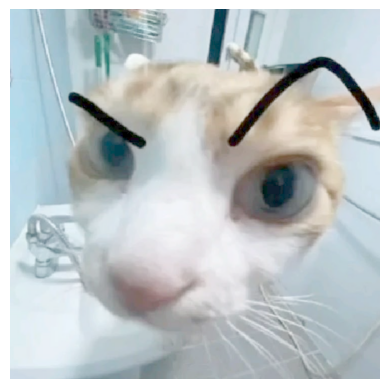

In [21]:
def gamma_correction(image, gamma):
    norm = image/255.0
    corrected = np.power(norm, gamma)
    return np.uint8(corrected*255)

gamma_img = gamma_correction(img, 0.5)

plt.imshow(cv2.cvtColor(gamma_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

4)Assign L-1 to range

(-0.5, 735.5, 735.5, -0.5)

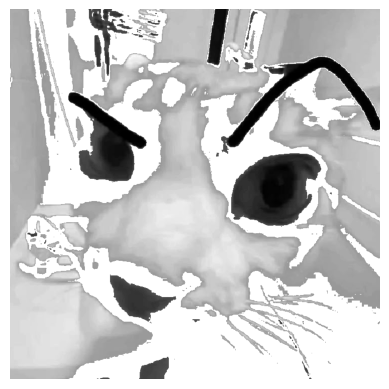

In [23]:
def intensity_range(image, A, B):
    result = image.copy()
    mask = (result >= A) & (result <= B)
    result[mask] = 255
    return result

range_img = intensity_range(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 80,150)

plt.imshow(range_img, cmap='gray')
plt.axis("off")

5)Image enchancment

(-0.5, 735.5, 735.5, -0.5)

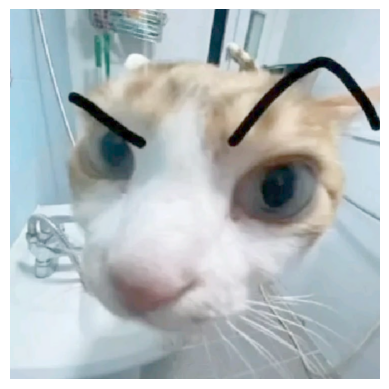

In [24]:
enhanced = gamma_correction(img, 0.6)

plt.imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
plt.axis("off")

PART 3
1)Bit-plane slicing

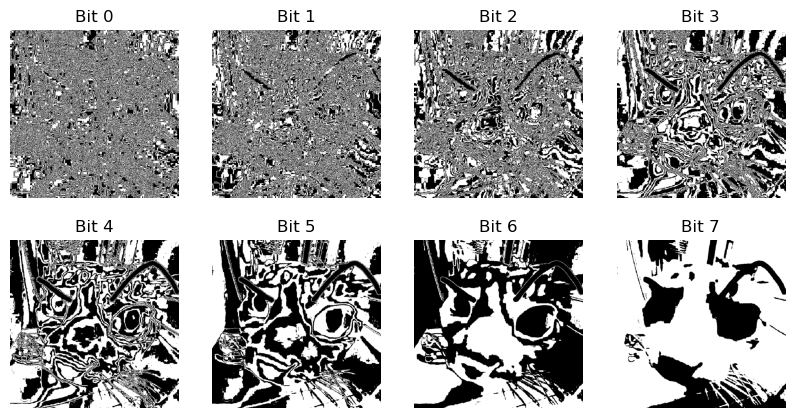

In [25]:
def displayBitResponse(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(10,5))
    for i in range(8):
        bit = (gray >> i) & 1
        plt.subplot(2,4,i+1)
        plt.imshow(bit, cmap='gray')
        plt.title(f"Bit {i}")
        plt.axis("off")

displayBitResponse(img)


### Report — Lab 4
First, image flipping operations were performed to create horizontal, vertical, and mirror effects. These operations helped to understand spatial manipulation of images.

Next, intensity transformations were studied. Image negative transformation inverted pixel values and highlighted hidden details. Gamma correction was applied using different gamma values to control image brightness. When images were not normalized, gamma curves did not meet at 255 because intensity values were not scaled. After normalization, curves met at 1 since all values were in the same range.

Intensity range transformation was also implemented to enhance selected pixel values. Bit-plane slicing was used to analyze the contribution of individual bits to the image structure. Higher bit planes contained most visual information, while lower planes mainly contained noise.

Overall, this lab provided practical understanding of intensity manipulation and image enhancement technicues.